# Genesis robot tutorial

This notebook demonstrates how to create and run a simple robot simulation in the Genesis backend using RobotBlockSet.

The workflow is:

- import Genesis and RobotBlockSet interfaces,
- create a Genesis scene from an MJCF model,
- add a Panda robot entity to the scene,
- wrap the Genesis entity with a RobotBlockSet robot interface,
- execute a short Cartesian and joint motion sequence,
- capture robot states during motion,
- plot measured and commanded joint/task trajectories.

This is a Genesis integration example for RobotBlockSet.


In [1]:
import time
import numpy as np
import math

import matplotlib.pyplot as plt

from robotblockset.tools import get_rbs_path

import genesis as gs
from robotblockset.genesis.robots_genesis import panda as panda_genesis

np.set_printoptions(precision=3, suppress=True, linewidth=100)

## Helper function for capturing robot states

The following callback stores robot time, joint states, task-space states, and commanded references during motion. The recorded arrays are later used for plotting measured and commanded trajectories.


In [2]:
it = 0
def CaptureRobot(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
    it += 1

Define the MJCF model used to construct the Genesis scene.


In [3]:
SCENE_PATH = get_rbs_path() + "/mujoco/mjcf_models/panda_scene.xml"
SHOW_VIEWER = True

# Initialize Genesis

Initialize the Genesis backend once before creating any scenes or entities. This example uses the GPU backend and reduces logging output.


In [4]:
gs.init(backend=gs.gpu, logging_level="warning")

# Create Genesis scene

A Genesis scene defines simulation timing, viewer settings, and the set of physical entities that will be simulated.


## Define scene

Configure the viewer camera, simulation timestep, and visualization options, then create the Genesis scene object.


In [5]:
scene = gs.Scene(
    viewer_options=gs.options.ViewerOptions(
        camera_pos=(0, -3.5, 2.5),
        camera_lookat=(0.0, 0.0, 0.5),
        camera_fov=30,
        res=(960, 640),
        max_FPS=60,
    ),
    sim_options=gs.options.SimOptions(
        dt=0.002,      ),
    show_viewer=SHOW_VIEWER,
)

## Add entities

Add the Panda robot from an MJCF model file. This allows the same robot description to be reused across simulation backends.


In [6]:
franka = scene.add_entity(
    gs.morphs.MJCF(
        file=SCENE_PATH,
    ),
)

[Genesis] [03:47:07] [WARNING] (MJCF) Approximating tendon by joint actuator for `panda_finger_joint1`
[Genesis] [03:47:07] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `panda_finger_joint1`.
[Genesis] [03:47:07] [WARNING] (MJCF) Approximating tendon by joint actuator for `panda_finger_joint2`
[Genesis] [03:47:07] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `panda_finger_joint2`.


d:\Leon\Python\RBS\.venv\Lib\site-packages\trimesh\triangles.py:302: RuntimeWarning: invalid value encountered in divide
  center_mass = integrated[1:4] / volume


## Build scene

Build the scene to finalize the model and allocate simulation objects before creating the RobotBlockSet wrapper.


In [7]:
scene.build()

[Genesis] [03:47:10] [WARNING] Constraint solver time constant should be greater than 2*substep_dt. timeconst is changed from `0.002` to `0.004`). Decrease simulation timestep or increase timeconst to avoid altering the original value.
[Genesis] [03:47:10] [WARNING] Neutral robot position (qpos0) exceeds joint limits.
[Genesis] [03:47:15] [WARNING] Filtered out geometry pairs causing self-collision for the neutral configuration (qpos0): (6, 11), (7, 11), (14, 21), (15, 20), (16, 23), (17, 22). Consider tuning Morph option 'decompose_robot_error_threshold' or specify dedicated collision meshes. This behavior can be disabled by setting Morph option 'enable_neutral_collision=True'.


d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)
d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var MJ_GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)


## Create robot object

Wrap the Genesis entity with the RobotBlockSet `panda_genesis` interface so standard RobotBlockSet commands can be used.


In [8]:
r = panda_genesis(scene=scene, robot_entity=franka, robot_name="panda")

[RBS_INFO] [03:47:57.634] [panda_Genesis]: Robot connected to Genesis


# Move robot

Reset the robot, start state capture, execute a short Cartesian move, return to the home configuration with a joint move, and then stop capture.


In [9]:
r.Restart(u=r.q_home)
r.Wait(2)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0, 0.2, -0.1], t=1)
r.Wait(1)
r.JMove(r.q_home, t=1)
r.Wait(1)
r.StopCapture()


Plot measured and commanded joint positions and velocities.


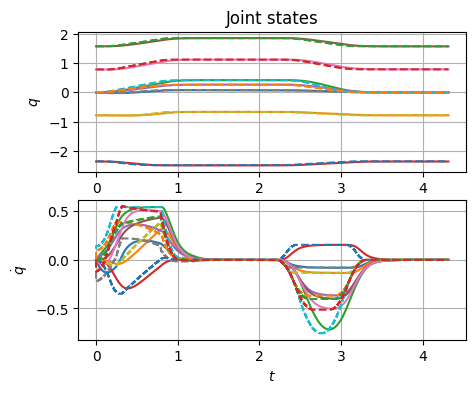

In [10]:
fig, ax = plt.subplots(2, 1, num=1, figsize=(5, 4))
ax[0].plot(tt, qt, "-")
ax[0].plot(tt, rqt, "--")
ax[0].grid()
ax[0].set_ylabel("$q$")
ax[0].set_title("Joint states")
ax[1].plot(tt, qdt, "-")
ax[1].plot(tt, rqdt, "--")
ax[1].grid()
ax[1].set_ylabel("$\\dot q$")
_ = ax[1].set_xlabel("$t$")

Plot measured and commanded task-space positions and linear velocities.


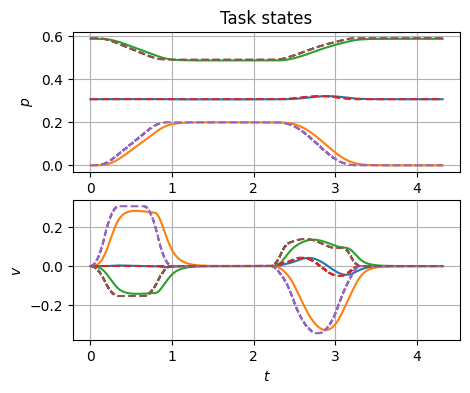

In [11]:
fig, ax = plt.subplots(2, 1, num=1, figsize=(5, 4))
ax[0].plot(tt, xt[:, :3], "-")
ax[0].plot(tt, rxt[:, :3], "--")
ax[0].grid()
ax[0].set_ylabel("$p$")
ax[0].set_title("Task states")
ax[1].plot(tt, vt[:, :3], "-")
ax[1].plot(tt, rvt[:, :3], "--")
ax[1].grid()
ax[1].set_ylabel("$v$")
_ = ax[1].set_xlabel("$t$")